In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam,SGD,Adagrad

In [2]:
data=pd.read_csv('iris.csv')

In [4]:
data.columns

Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'variety'],
      dtype='object')

In [5]:
data['variety'].unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

In [6]:
data['variety']=data['variety'].map({'Setosa':0,'Versicolor':1,'Virginica':2})

In [7]:
data

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
x=data.drop('variety',axis=1)
y=data[ 'variety']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [10]:
model = Sequential()
model.add(Dense(10, input_dim = 4, kernel_initializer='uniform' ,activation = 'relu'))
model.add(Dense(12, kernel_initializer='uniform', activation= 'relu'))
model.add(Dense(15, kernel_initializer='uniform', activation= 'relu'))
model.add(Dense(25, activation= 'relu'))

model.add(Dense(3, kernel_initializer='uniform', activation= 'softmax'))


callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=10)
model.compile(loss = 'sparse_categorical_crossentropy',optimizer = Adam(learning_rate=0.01), metrics=['accuracy'])
model.summary()

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 15)                  │             195 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 25)                  │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              78 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 855 (3.34 KB)

 Trainable params: 855 (3.34 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
training_info = model.fit(x_train,y_train,batch_size=5,epochs=100,validation_data=(x_test,y_test),callbacks=callbacks)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3222 - loss: 1.0995 - val_accuracy: 0.2000 - val_loss: 1.1100
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3667 - loss: 1.0954 - val_accuracy: 0.2000 - val_loss: 1.1189
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3405 - loss: 1.0491 - val_accuracy: 0.5333 - val_loss: 0.9244
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6582 - loss: 0.7766 - val_accuracy: 0.5667 - val_loss: 0.8246
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6546 - loss: 0.7290 - val_accuracy: 0.5667 - val_loss: 0.8577
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7385 - loss: 0.6587 - val_accuracy: 0.5667 - val_loss: 0.7364
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8205 - loss: 0.5460 - val_accuracy: 0.6000 - val_loss: 0.7137
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7413 - loss: 0.5182 - val_accuracy: 0.8000 - v

In [12]:
hist=training_info.history

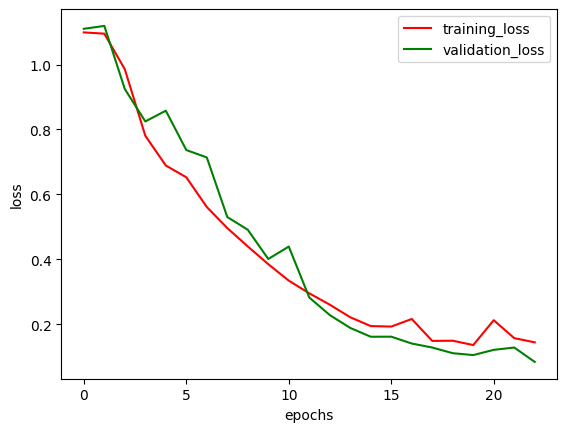

In [13]:
plt.plot(hist['loss'],label='training_loss',color='red')
plt.plot(hist['val_loss'],label='validation_loss',color='green')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()


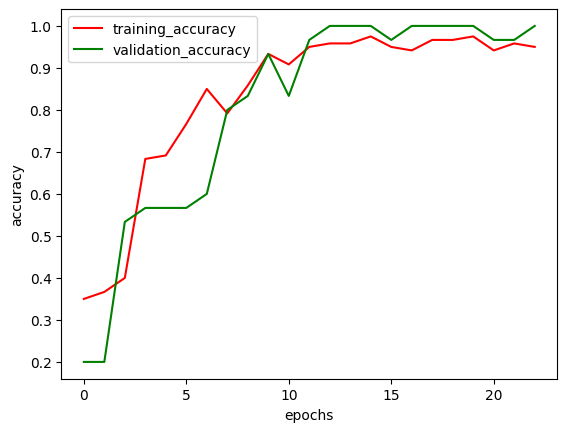

In [14]:
plt.plot(hist['accuracy'],label='training_accuracy',color='red')
plt.plot(hist['val_accuracy'],label='validation_accuracy',color='green')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

In [15]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [16]:
y_pred

array([[9.1184628e-01, 6.9154300e-02, 1.8999398e-02],
       [1.0585711e-01, 7.9425102e-01, 9.9891819e-02],
       [2.9081550e-06, 9.7552401e-01, 2.4473116e-02],
       [9.1184628e-01, 6.9154300e-02, 1.8999398e-02],
       [3.1242835e-18, 1.3025607e-01, 8.6974394e-01],
       [9.8509272e-09, 9.4642097e-01, 5.3579058e-02],
       [2.6930322e-20, 5.5505238e-02, 9.4449478e-01],
       [9.1184628e-01, 6.9154300e-02, 1.8999398e-02],
       [9.1184628e-01, 6.9154300e-02, 1.8999398e-02],
       [2.9496345e-24, 9.8789046e-03, 9.9012113e-01],
       [6.9039766e-07, 9.7880805e-01, 2.1191265e-02],
       [9.1184628e-01, 6.9154300e-02, 1.8999398e-02],
       [3.7125640e-23, 1.6043095e-02, 9.8395687e-01],
       [3.1936042e-07, 9.7583950e-01, 2.4160165e-02],
       [8.7291712e-09, 9.4495100e-01, 5.5049002e-02],
       [9.1184628e-01, 6.9154300e-02, 1.8999398e-02],
       [3.2731907e-05, 9.6730208e-01, 3.2665178e-02],
       [2.0400466e-09, 9.2411423e-01, 7.5885803e-02],
       [9.1184628e-01, 6.915

In [19]:
y_pred=np.argmax(y_pred,axis=1)

In [20]:
pd.DataFrame({'True values':y_test,'Prediction values':y_pred})

,True values,Prediction values
14,0,0
98,1,1
75,1,1
16,0,0
131,2,2
56,1,1
141,2,2
44,0,0
29,0,0
120,2,2
